# One-Period Debt with Sunspots and (g,s)-Dependent LOLR Policy

This notebook solves the one-period debt model with a single LOLR rate and a LOLR quantity cap that depends only on the current growth and sunspot state `(g,s)`.

- State: private debt `b`, LOLR debt `l`, growth `g`, sunspot `s`, shock `eps`.
- Choice in repayment: next private debt `b'` and next LOLR debt `l'`.
- Choice in default: next LOLR debt `l'` only.
- Current baseline: `\sigma = 8\%`, `\Delta(g_L,s_B)=20\%`, and `\Delta=5\%` in all other states.


In [1]:
using Statistics
include("src/simple_s_lolr_v2.jl")
Threads.nthreads()

8

In [2]:
# Baseline (d,g,s)-dependent LOLR calibration.
# LOLR spread is σ = 8% in all states.
# Δ is large only in (no default, g_L, s_B): 20%.
# Δ = 5% in all other (d, g, s) states.
Δ_dgs = fill(0.05, 2, 2, 2)
Δ_dgs[1, 1, 1] = 0.20
model = init_model(Model(
    Nb = 800,
    Nl = 20,
    Ne = 5,
    R_l = 1.115,
    Δ_dgs = Δ_dgs,
))
model.max_iter = 50
model.max_iter_vd = 100
model.max_iter_x = 100
model.pub = 0.65
model


Model(800, 20, 2, 2, 5, -0.05, 1.0, 0.0, 0.2018461538461538, [-0.05, -0.048685857321652065, -0.04737171464330413, -0.0460575719649562, -0.04474342928660826, -0.04342928660826033, -0.04211514392991239, -0.04080100125156445, -0.03948685857321652, -0.038172715894868585  …  0.9881727158948685, 0.9894868585732165, 0.9908010012515645, 0.9921151439299124, 0.9934292866082604, 0.9947434292866083, 0.9960575719649561, 0.9973717146433041, 0.998685857321652, 1.0], [0.0, 0.010623481781376514, 0.02124696356275303, 0.03187044534412955, 0.04249392712550606, 0.053117408906882574, 0.0637408906882591, 0.0743643724696356, 0.08498785425101212, 0.09561133603238864, 0.10623481781376515, 0.11685829959514167, 0.1274817813765182, 0.1381052631578947, 0.1487287449392712, 0.15935222672064772, 0.16997570850202423, 0.18059919028340077, 0.19122267206477728, 0.2018461538461538], [0.96, 1.04], [-2.5, -1.25, 0.0, 1.25, 2.5], [0.6 0.4; 0.25 0.75], [0.25 0.75; 0.25 0.75], [0.030396361765261396, 0.2355891672834392, 0.468028

In [3]:
# Time the main steps inside solve_model.
function time_solve_steps(model; n_iter = min(1, model.max_iter))
    sol = initial_solution(model)
    l = model.l
    y = reshape(model.g, model.Ng, 1) .* exp.(model.sigma_eps .* reshape(model.eps, 1, model.Ne))
    g_beta = model.beta .* (model.g .^ (1 - model.gamma))
    gb = reshape(model.b, model.Nb, 1, 1, 1) .* reshape(model.g, 1, 1, model.Ng, 1)
    bprime_idx = nearest_index(model.b, model.b ./ reshape(model.g, 1, model.Ng))
    kbprime_idx = nearest_index(model.b, model.kappa .* model.b ./ reshape(model.g, 1, model.Ng))
    b0_idx = findmin(abs.(model.b))[2]
    l0_idx = findmin(abs.(l))[2]

    vnd = copy(sol.vnd)
    vd = copy(sol.vd)
    X = copy(sol.X)
    d = copy(sol.d)
    e = copy(sol.e)
    QE = Array{Float64}(undef, model.Nb, model.Nl, model.Ng, model.Ns)
    R = copy(sol.R)
    n = copy(sol.n)
    pdefault = copy(sol.pdefault)
    QE_tmp = Vector{Float64}(undef, model.Nb * model.Nl * model.Ng * model.Ns)
    pdefault_tmp = similar(QE_tmp)
    l_policy_idx_d = copy(sol.l_policy_idx_d)

    t_vd = 0.0
    t_default = 0.0
    t_prices = 0.0
    t_schedule = 0.0
    t_mask = 0.0
    t_vnd = 0.0

    for it in 1:n_iter
        damp = max(0.05, 0.9 - 0.0 * ((it - 1) / 10))

        t_vd += @elapsed begin
            vd_err, l_policy_idx_d = _solve_vd!(vd, vnd, model, y, g_beta, bprime_idx, kbprime_idx)
        end

        t_default += @elapsed begin
            d = vnd .< vd
            e = .!d
        end

        t_prices += @elapsed begin
            Q, x_err = _solve_prices!(X, d, e, model, bprime_idx, kbprime_idx, l_policy_idx_d)
        end

        t_schedule += @elapsed begin
            _compute_schedule!(QE, R, n, pdefault, model, Q, d, gb, QE_tmp, pdefault_tmp)
        end

        t_mask += @elapsed begin
            schedule_mask = _select_schedule_mask(n, R, pdefault, model)
        end

        t_vnd += @elapsed begin
            err = _update_vnd!(vnd, vd, model, y, g_beta, n, pdefault, schedule_mask, b0_idx, l0_idx; damp = damp)
        end

        println("iter=", it, ", vnd_err=", err, ", vd_err=", vd_err, ", x_err=", x_err)
    end

    println()
    println("Timing over ", n_iter, " outer iterations")
    println("  solve_vd:        ", round(t_vd, digits = 3), " s")
    println("  default_reentry: ", round(t_default, digits = 3), " s")
    println("  solve_prices:    ", round(t_prices, digits = 3), " s")
    println("  compute_schedule:", round(t_schedule, digits = 3), " s")
    println("  select_mask:     ", round(t_mask, digits = 3), " s")
    println("  update_vnd:      ", round(t_vnd, digits = 3), " s")
    return nothing
end

time_solve_steps(model)


iter=1, vnd_err=4.778641358845881, vd_err=8.719657511591095e-7, x_err=9.195571140097059e-7

Timing over 1 outer iterations
  solve_vd:        0.185 s
  default_reentry: 0.001 s
  solve_prices:    2.094 s
  compute_schedule:0.002 s
  select_mask:     0.007 s
  update_vnd:      4.512 s


## Step-by-Step Diagnostics

These cells mimic the steps inside `solve_model`, one block at a time. Run them in order to see which block looks wrong before the full outer fixed point is used.

In [4]:
using Plots

function make_debug_state(model)
    sol = initial_solution(model)
    l = model.l
    y = reshape(model.g, model.Ng, 1) .* exp.(model.sigma_eps .* reshape(model.eps, 1, model.Ne))
    g_beta = model.beta .* (model.g .^ (1 - model.gamma))
    gb = reshape(model.b, model.Nb, 1, 1, 1) .* reshape(model.g, 1, 1, model.Ng, 1)
    bprime_idx = nearest_index(model.b, model.b ./ reshape(model.g, 1, model.Ng))
    kbprime_idx = nearest_index(model.b, model.kappa .* model.b ./ reshape(model.g, 1, model.Ng))
    b0_idx = findmin(abs.(model.b))[2]
    l0_idx = findmin(abs.(l))[2]
    QE = Array{Float64}(undef, model.Nb, model.Nl, model.Ng, model.Ns)
    QE_tmp = Vector{Float64}(undef, model.Nb * model.Nl * model.Ng * model.Ns)
    pdefault_tmp = similar(QE_tmp)

    return Dict{Symbol, Any}(
        :vnd => copy(sol.vnd),
        :vd => copy(sol.vd),
        :X => copy(sol.X),
        :Q => copy(sol.Q),
        :d => copy(sol.d),
        :e => copy(sol.e),
        :R => copy(sol.R),
        :n => copy(sol.n),
        :pdefault => copy(sol.pdefault),
        :schedule_mask => copy(sol.schedule_mask),
        :l_policy_idx_d => copy(sol.l_policy_idx_d),
        :QE => QE,
        :QE_tmp => QE_tmp,
        :pdefault_tmp => pdefault_tmp,
        :y => y,
        :g_beta => g_beta,
        :gb => gb,
        :bprime_idx => bprime_idx,
        :kbprime_idx => kbprime_idx,
        :b0_idx => b0_idx,
        :l0_idx => l0_idx,
    )
end

dbg = make_debug_state(model)
e_idx = cld(model.Ne, 2)
l_idx = 1
gi = 1
s_bad = 1
s_good = min(2, model.Ns)

println("Debug state ready.")
println("Use gi=", gi, ", l_idx=", l_idx, ", e_idx=", e_idx)


Debug state ready.
Use gi=1, l_idx=1, e_idx=3


vd_err = 8.719657511591095e-7


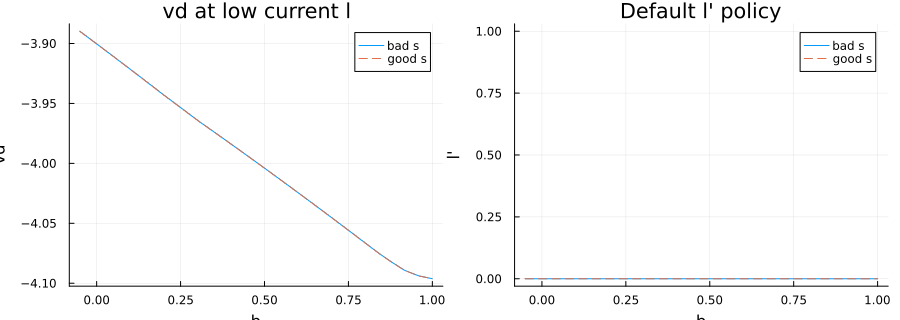

In [5]:
# Step 2: solve vd given current vnd.
vd_err, dbg[:l_policy_idx_d] = _solve_vd!(dbg[:vd], dbg[:vnd], model, dbg[:y], dbg[:g_beta], dbg[:bprime_idx], dbg[:kbprime_idx])
println("vd_err = ", vd_err)

p1 = plot(model.b, dbg[:vd][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "vd", title = "vd at low current l")
plot!(p1, model.b, dbg[:vd][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

p2 = plot(model.b, model.l[dbg[:l_policy_idx_d][:, l_idx, gi, s_bad, e_idx]], label = "bad s", xlabel = "b", ylabel = "l'", title = "Default l' policy")
plot!(p2, model.b, model.l[dbg[:l_policy_idx_d][:, l_idx, gi, s_good, e_idx]], label = "good s", linestyle = :dash)

plot(p1, p2, layout = (1, 2), size = (900, 320))


Mean default probability in grid = 0.88158125


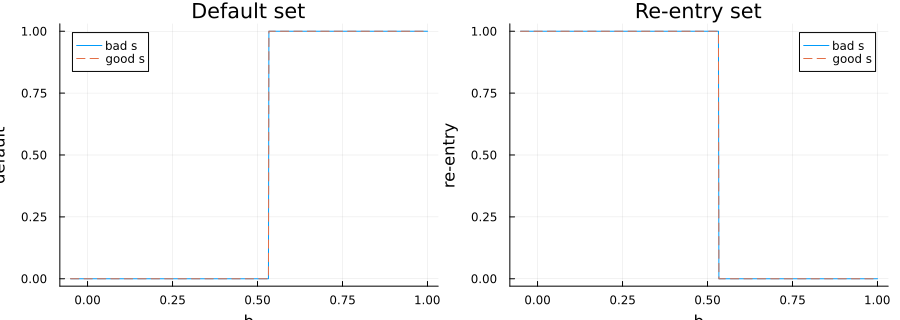

In [6]:
# Step 3: default and re-entry from vnd and vd.
dbg[:d] = dbg[:vnd] .< dbg[:vd]
dbg[:e] = .!dbg[:d]
println("Mean default probability in grid = ", mean(dbg[:d]))

p1 = plot(model.b, Float64.(dbg[:d][:, l_idx, gi, s_bad, e_idx]), label = "bad s", xlabel = "b", ylabel = "default", title = "Default set")
plot!(p1, model.b, Float64.(dbg[:d][:, l_idx, gi, s_good, e_idx]), label = "good s", linestyle = :dash)

p2 = plot(model.b, Float64.(dbg[:e][:, l_idx, gi, s_bad, e_idx]), label = "bad s", xlabel = "b", ylabel = "re-entry", title = "Re-entry set")
plot!(p2, model.b, Float64.(dbg[:e][:, l_idx, gi, s_good, e_idx]), label = "good s", linestyle = :dash)

plot(p1, p2, layout = (1, 2), size = (900, 320))


x_err = 9.195571140097059e-7


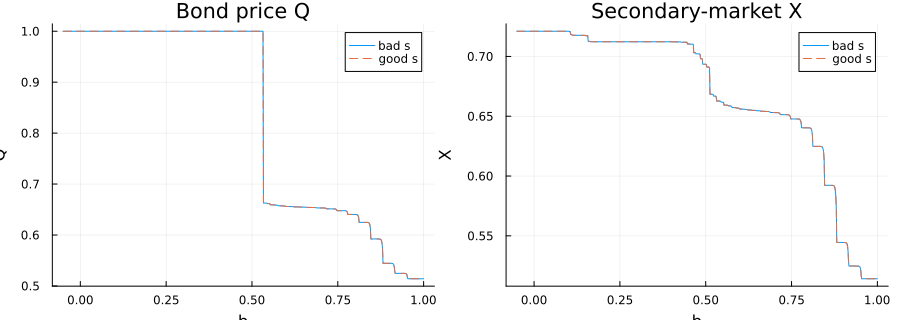

In [7]:
# Step 4: solve prices Q and X given d, e, and default l' policy.
dbg[:Q], x_err = _solve_prices!(dbg[:X], dbg[:d], dbg[:e], model, dbg[:bprime_idx], dbg[:kbprime_idx], dbg[:l_policy_idx_d])
println("x_err = ", x_err)

p1 = plot(model.b, dbg[:Q][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "Q", title = "Bond price Q")
plot!(p1, model.b, dbg[:Q][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

p2 = plot(model.b, dbg[:X][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "X", title = "Secondary-market X")
plot!(p2, model.b, dbg[:X][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

plot(p1, p2, layout = (1, 2), size = (900, 320))


Bad-sunspot available points = 15947
Good-sunspot available points = 16000


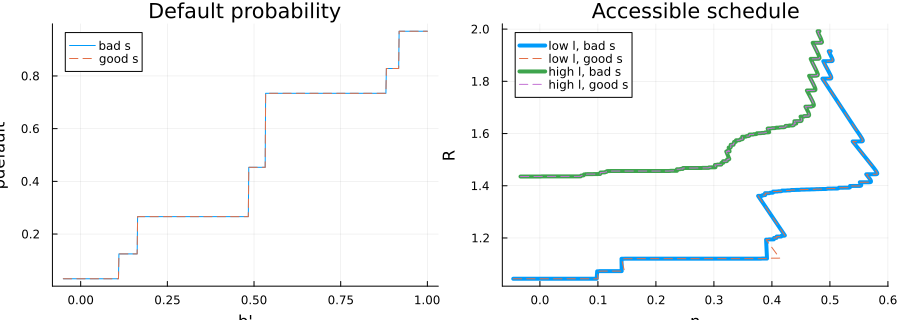

In [8]:
# Step 5: schedules and sunspot mask given Q and d.
_compute_schedule!(dbg[:QE], dbg[:R], dbg[:n], dbg[:pdefault], model, dbg[:Q], dbg[:d], dbg[:gb], dbg[:QE_tmp], dbg[:pdefault_tmp])
dbg[:schedule_mask] = _select_schedule_mask(dbg[:n], dbg[:R], dbg[:pdefault], model)

mask_bad = dbg[:schedule_mask][:, :, gi, s_bad]
mask_good = dbg[:schedule_mask][:, :, gi, s_good]
println("Bad-sunspot available points = ", count(mask_bad))
println("Good-sunspot available points = ", count(mask_good))
l_low = 1
l_high = model.Nl

function masked_line(x, y, mask)
    return x,y
end

p1 = plot(model.b, dbg[:pdefault][:, l_idx, gi, s_bad], label = "bad s", xlabel = "b'", ylabel = "pdefault", title = "Default probability")
plot!(p1, model.b, dbg[:pdefault][:, l_idx, gi, s_good], label = "good s", linestyle = :dash)

mask_bad_low = dbg[:schedule_mask][:, l_low, gi, s_bad]
mask_good_low = dbg[:schedule_mask][:, l_low, gi, s_good]
mask_bad_high = dbg[:schedule_mask][:, l_high, gi, s_bad]
mask_good_high = dbg[:schedule_mask][:, l_high, gi, s_good]

n_bad_low = dbg[:n][mask_bad_low, l_low, gi, s_bad]
R_bad_low = dbg[:R][mask_bad_low, l_low, gi, s_bad]
n_good_low = dbg[:n][mask_good_low, l_low, gi, s_good]
R_good_low = dbg[:R][mask_good_low, l_low, gi, s_good]
n_bad_high = dbg[:n][mask_bad_high, l_high, gi, s_bad]
R_bad_high = dbg[:R][mask_bad_high, l_high, gi, s_bad]
n_good_high = dbg[:n][mask_good_high, l_high, gi, s_good]
R_good_high = dbg[:R][mask_good_high, l_high, gi, s_good]

p2 = plot(n_bad_low, R_bad_low, label = "low l, bad s", xlabel = "n", ylabel = "R", title = "Accessible schedule", linewidth = 4)
plot!(p2, n_good_low, R_good_low, label = "low l, good s", linestyle = :dash, linewidth = 1)
plot!(p2, n_bad_high, R_bad_high, label = "high l, bad s", linewidth = 4)
plot!(p2, n_good_high, R_good_high, label = "high l, good s", linestyle = :dash, linewidth = 1)

plot(p1, p2, layout = (1, 2), size = (900, 320))


Final vnd_err = 4.778641358845881


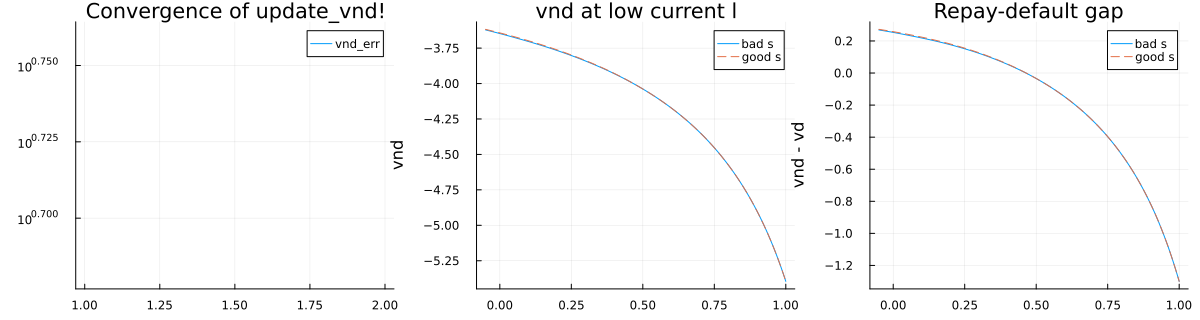

In [9]:
# Step 6: update vnd given the current schedules, jusdt one iteration to check the error and convergence. The full iteration is done in time_solve_steps.
vnd_errs = Float64[]
for it in 1:1
    err = _update_vnd!(dbg[:vnd], dbg[:vd], model, dbg[:y], dbg[:g_beta], dbg[:n], dbg[:pdefault], dbg[:schedule_mask], dbg[:b0_idx], dbg[:l0_idx]; damp = 0.9)
    push!(vnd_errs, err)
    err < model.tol && break
end
println("Final vnd_err = ", last(vnd_errs))

p1 = plot(vnd_errs, yscale = :log10, xlabel = "step-6 iteration", ylabel = "error", label = "vnd_err", title = "Convergence of update_vnd!")

p2 = plot(model.b, dbg[:vnd][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "vnd", title = "vnd at low current l")
plot!(p2, model.b, dbg[:vnd][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

p3 = plot(model.b, dbg[:vnd][:, l_idx, gi, s_bad, e_idx] .- dbg[:vd][:, l_idx, gi, s_bad, e_idx], label = "bad s", xlabel = "b", ylabel = "vnd - vd", title = "Repay-default gap")
plot!(p3, model.b, dbg[:vnd][:, l_idx, gi, s_good, e_idx] .- dbg[:vd][:, l_idx, gi, s_good, e_idx], label = "good s", linestyle = :dash)

plot(p1, p2, p3, layout = (1, 3), size = (1200, 320))


In [10]:
sol = solve_model(model; verbose = true)
println("Mean default probability in the state grid = ", mean(sol.d))
println("Final outer error = ", sol.outer_errs[end])

iter=1, vnd_err=4.778641358845881, vd_err=8.719657511591095e-7, x_err=9.195571140097059e-7, damp=0.9
iter=2, vnd_err=11.08470927693759, vd_err=8.466923073768839e-7, x_err=0.00019413789664082803, damp=0.9
iter=3, vnd_err=11.709545489796877, vd_err=6.998417401149482e-7, x_err=1.3922782461081584e-5, damp=0.9
iter=4, vnd_err=5.08931558257569, vd_err=9.531422140440782e-7, x_err=1.4461959946143743e-5, damp=0.9
iter=5, vnd_err=3.4958503860494936, vd_err=9.029110827896147e-7, x_err=1.4098346666754913e-5, damp=0.9
iter=6, vnd_err=2.1577613860401, vd_err=7.217312951723898e-7, x_err=1.1098523350197564e-5, damp=0.9
iter=7, vnd_err=1.6934103235269617, vd_err=8.662719839236388e-7, x_err=1.0367275551009802e-5, damp=0.9
iter=8, vnd_err=1.1143193715144584, vd_err=7.853548433800484e-7, x_err=9.168505725354326e-6, damp=0.9
iter=9, vnd_err=0.7904258556806063, vd_err=7.166674151903862e-7, x_err=7.312965994626941e-6, damp=0.9
iter=10, vnd_err=0.6172508881909486, vd_err=8.392389485578633e-7, x_err=4.86982638

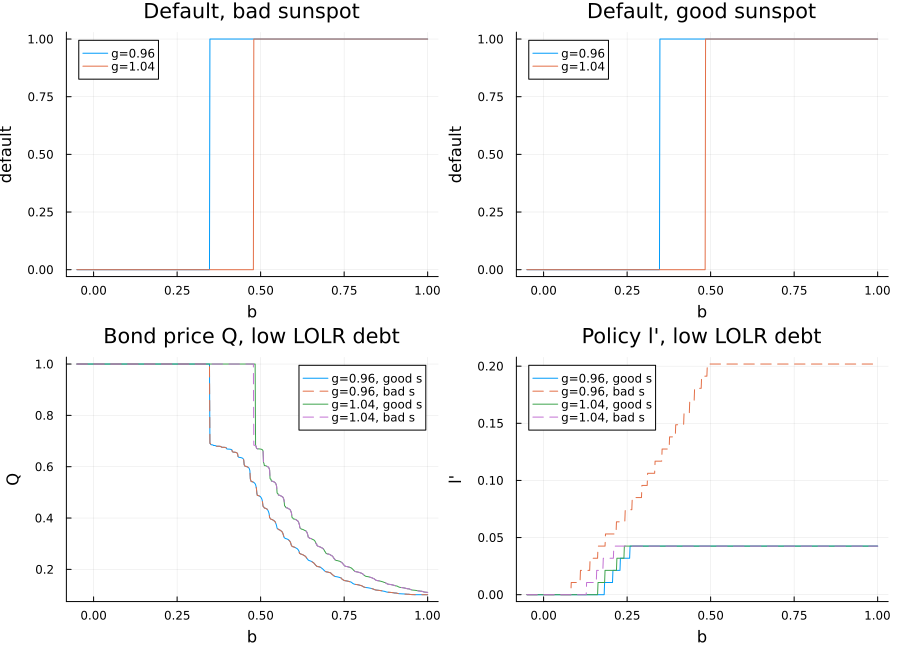

In [11]:
using Plots

b = model.b
l = model.l
g = model.g
e_idx = cld(model.Ne, 2)
l_idx = 1
s_bad = 1
s_good = 2

p1 = plot(title = "Default, bad sunspot", xlabel = "b", ylabel = "default")
p2 = plot(title = "Default, good sunspot", xlabel = "b", ylabel = "default")
p3 = plot(title = "Bond price Q, low LOLR debt", xlabel = "b", ylabel = "Q")
p4 = plot(title = "Policy l', low LOLR debt", xlabel = "b", ylabel = "l'")

for gi in 1:model.Ng
    plot!(p1, b, Float64.(sol.d[:, l_idx, gi, s_bad, e_idx]), label = "g=$(g[gi])")
    plot!(p2, b, Float64.(sol.d[:, l_idx, gi, s_good, e_idx]), label = "g=$(g[gi])")
    plot!(p3, b, sol.Q[:, l_idx, gi, s_good, e_idx], label = "g=$(g[gi]), good s")
    plot!(p3, b, sol.Q[:, l_idx, gi, s_bad, e_idx], linestyle = :dash, label = "g=$(g[gi]), bad s")
    plot!(p4, b, l[sol.l_policy_idx[:, l_idx, gi, s_good, e_idx]], label = "g=$(g[gi]), good s")
    plot!(p4, b, l[sol.l_policy_idx[:, l_idx, gi, s_bad, e_idx]], linestyle = :dash, label = "g=$(g[gi]), bad s")
end

plot(p1, p2, p3, p4, layout = (2, 2), size = (900, 650))

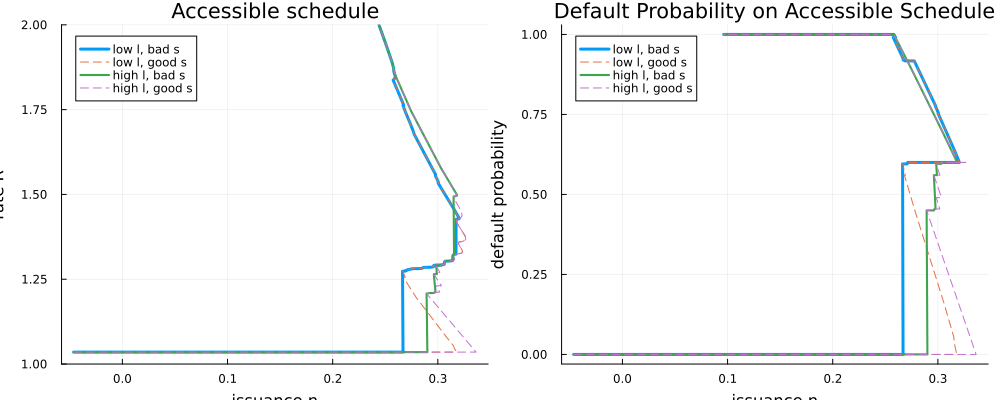

In [12]:
# Compare the available schedule lines for low and high l'.
gi = 1
l_low = 1
l_high = 10

mask_bad_low = sol.schedule_mask[:, l_low, gi, s_bad]
mask_good_low = sol.schedule_mask[:, l_low, gi, s_good]
mask_bad_high = sol.schedule_mask[:, l_high, gi, s_bad]
mask_good_high = sol.schedule_mask[:, l_high, gi, s_good]

n_bad_low = sol.n[mask_bad_low, l_low, gi, s_bad]
R_bad_low = sol.R[mask_bad_low, l_low, gi, s_bad]
n_good_low = sol.n[mask_good_low, l_low, gi, s_good]
R_good_low = sol.R[mask_good_low, l_low, gi, s_good]
n_bad_high = sol.n[mask_bad_high, l_high, gi, s_bad]
R_bad_high = sol.R[mask_bad_high, l_high, gi, s_bad]
n_good_high = sol.n[mask_good_high, l_high, gi, s_good]
R_good_high = sol.R[mask_good_high, l_high, gi, s_good]

n_bad_low_pd = sol.n[mask_bad_low, l_low, gi, s_bad]
p_bad_low = sol.pdefault[mask_bad_low, l_low, gi, s_bad]
n_good_low_pd = sol.n[mask_good_low, l_low, gi, s_good]
p_good_low = sol.pdefault[mask_good_low, l_low, gi, s_good]
n_bad_high_pd = sol.n[mask_bad_high, l_high, gi, s_bad]
p_bad_high = sol.pdefault[mask_bad_high, l_high, gi, s_bad]
n_good_high_pd = sol.n[mask_good_high, l_high, gi, s_good]
p_good_high = sol.pdefault[mask_good_high, l_high, gi, s_good]

p_sched = plot(n_bad_low, R_bad_low, label = "low l, bad s", xlabel = "issuance n", ylabel = "rate R", title = "Accessible schedule", linewidth = 3,ylims=(1.0, 2.0))
plot!(p_sched, n_good_low, R_good_low, label = "low l, good s", linestyle = :dash, linewidth = 1)
plot!(p_sched, n_bad_high, R_bad_high, label = "high l, bad s", linewidth = 2.1)
plot!(p_sched, n_good_high, R_good_high, label = "high l, good s", linestyle = :dash, linewidth = 1)

p_def = plot(n_bad_low_pd, p_bad_low, label = "low l, bad s", xlabel = "issuance n", ylabel = "default probability", title = "Default Probability on Accessible Schedule", linewidth = 3)
plot!(p_def, n_good_low_pd, p_good_low, label = "low l, good s", linestyle = :dash, linewidth = 1)
plot!(p_def, n_bad_high_pd, p_bad_high, label = "high l, bad s", linewidth = 2.1)
plot!(p_def, n_good_high_pd, p_good_high, label = "high l, good s", linestyle = :dash, linewidth = 1)

plot(p_sched, p_def, layout = (1, 2), size = (1000, 400))

In [13]:
# State indices and repayment-policy objects on the full (b,l) grid
gi_low = argmin(model.g)
gi_high = argmax(model.g)
ei_mid = cld(model.Ne, 2)
s_bad = 1
s_good = model.Ns

function repayment_policy_objects(model, sol; gi, si, ei)
    Nb, Nl = model.Nb, model.Nl
    n_pol  = Matrix{Float64}(undef, Nb, Nl)
    nl_pol = Matrix{Float64}(undef, Nb, Nl)
    bp_pol = Matrix{Float64}(undef, Nb, Nl)
    lp_pol = Matrix{Float64}(undef, Nb, Nl)
    d_pol  = Matrix{Float64}(undef, Nb, Nl)

    for bi in 1:Nb, li in 1:Nl
        bp_idx = sol.b_policy_idx[bi, li, gi, si, ei]
        lp_idx = sol.l_policy_idx[bi, li, gi, si, ei]

        bp = model.b[bp_idx]
        lp = model.l[lp_idx]

        n_pol[bi, li]  = sol.n[bp_idx, lp_idx, gi, si]
        nl_pol[bi, li] = model.g[gi] * lp / model.R_l
        bp_pol[bi, li] = bp
        lp_pol[bi, li] = lp
        d_pol[bi, li]  = sol.d[bi, li, gi, si, ei] ? 1.0 : 0.0
    end

    share_pol = nl_pol ./ max.(n_pol .+ nl_pol, 1e-12)

    return (
        n = n_pol,
        n_l = nl_pol,
        share = share_pol,
        bprime = bp_pol,
        lprime = lp_pol,
        d = d_pol,
    )
end

pol_bad  = repayment_policy_objects(model, sol; gi = gi_low, si = s_bad,  ei = ei_mid)
pol_good = repayment_policy_objects(model, sol; gi = gi_low, si = s_good, ei = ei_mid)


(n = [0.22056556202499503 0.22666013676515936 … 0.3144220130235258 0.3144220130235258; 0.2217844769730279 0.22787905171319223 … 0.3144220130235258 0.3144220130235258; … ; 0.3273598748579625 0.3273598748579625 … 0.3273598748579625 0.3273598748579625; 0.3273598748579625 0.3273598748579625 … 0.3273598748579625 0.3273598748579625], n_l = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.036586699587879655 0.036586699587879655 … 0.036586699587879655 0.036586699587879655; 0.036586699587879655 0.036586699587879655 … 0.036586699587879655 0.036586699587879655], share = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.10052766575310636 0.10052766575310636 … 0.10052766575310636 0.10052766575310636; 0.10052766575310636 0.10052766575310636 … 0.10052766575310636 0.10052766575310636], bprime = [0.23779724655819776 0.24436795994993743 … 0.3389862327909887 0.3389862327909887; 0.23911138923654568 0.24568210262828535 … 0.3389862327909887 0.3389862327909887; … ; 0.353441802252816 0.353441802252816 … 0.353441802252

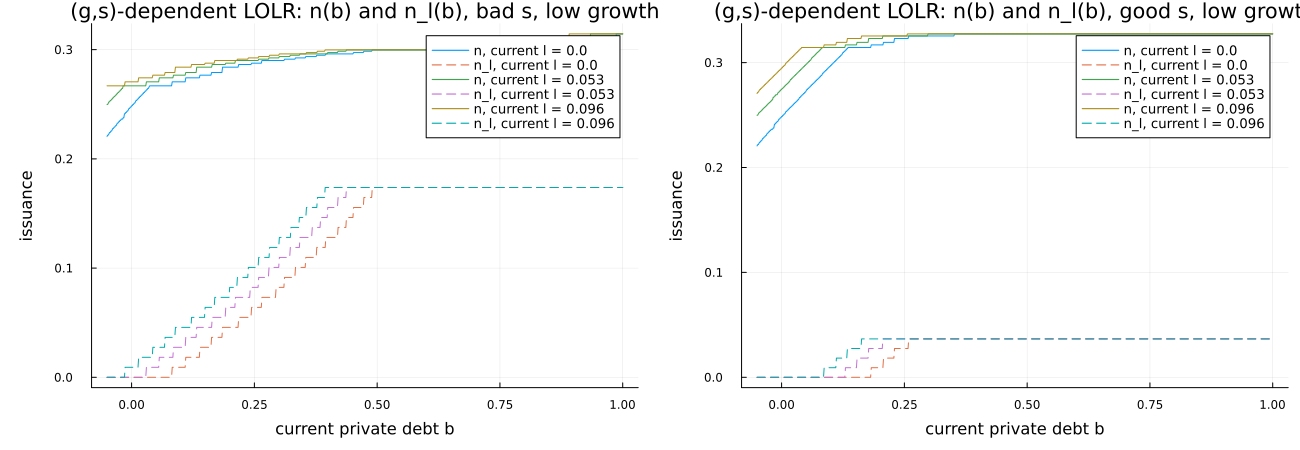

In [14]:
# n(b) and n_l(b) for a few fixed current l values, bad s and good s
using Plots

l_targets = [0.0, 0.05, 0.10]
l_idxs = [argmin(abs.(model.l .- x)) for x in l_targets]
slice_labels = ["current l = $(round(model.l[i], digits=3))" for i in l_idxs]

function plot_nb_nl_slices(model, pol, si_label, l_idxs, slice_labels)
    p = plot(
        xlabel = "current private debt b",
        ylabel = "issuance",
        title = "(g,s)-dependent LOLR: n(b) and n_l(b), $(si_label), low growth",
        legend = :topright,
        linewidth = 2.5,
        legendfontsize = 9,
        left_margin = 10Plots.mm,
        bottom_margin = 8Plots.mm,
    )

    for (k, li) in enumerate(l_idxs)
        plot!(p, model.b, pol.n[:, li],
            label = "n, " * slice_labels[k],
            linestyle = :solid)
        plot!(p, model.b, pol.n_l[:, li],
            label = "n_l, " * slice_labels[k],
            linestyle = :dash)
    end

    p
end

p_bad_slices  = plot_nb_nl_slices(model, pol_bad,  "bad s",  l_idxs, slice_labels)
p_good_slices = plot_nb_nl_slices(model, pol_good, "good s", l_idxs, slice_labels)

plot(p_bad_slices, p_good_slices, layout = (1, 2), size = (1300, 450))


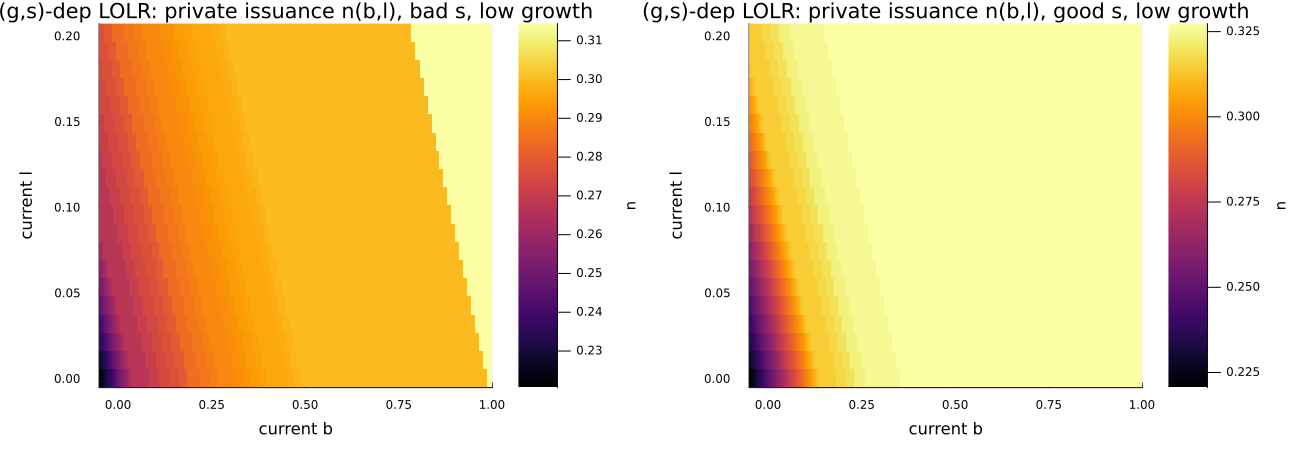

In [15]:
p1 = heatmap(
    model.b, model.l, pol_bad.n',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dep LOLR: private issuance n(b,l), bad s, low growth",
    colorbar_title = "n",
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

p2 = heatmap(
    model.b, model.l, pol_good.n',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dep LOLR: private issuance n(b,l), good s, low growth",
    colorbar_title = "n",
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

plot(p1, p2, layout = (1, 2), size = (1300, 450))


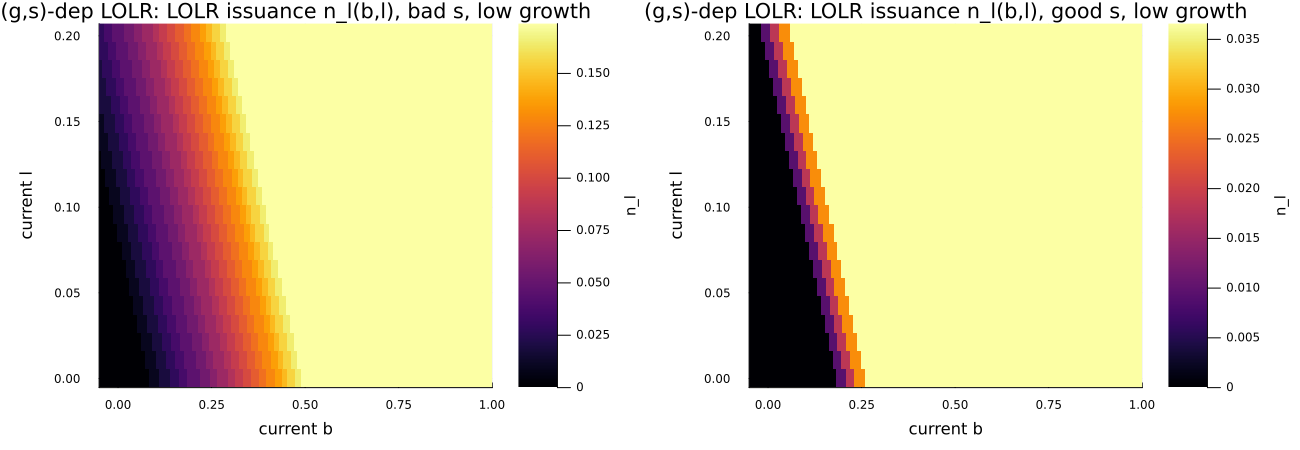

In [16]:
p1 = heatmap(
    model.b, model.l, pol_bad.n_l',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dep LOLR: LOLR issuance n_l(b,l), bad s, low growth",
    colorbar_title = "n_l",
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

p2 = heatmap(
    model.b, model.l, pol_good.n_l',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dep LOLR: LOLR issuance n_l(b,l), good s, low growth",
    colorbar_title = "n_l",
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

plot(p1, p2, layout = (1, 2), size = (1300, 450))


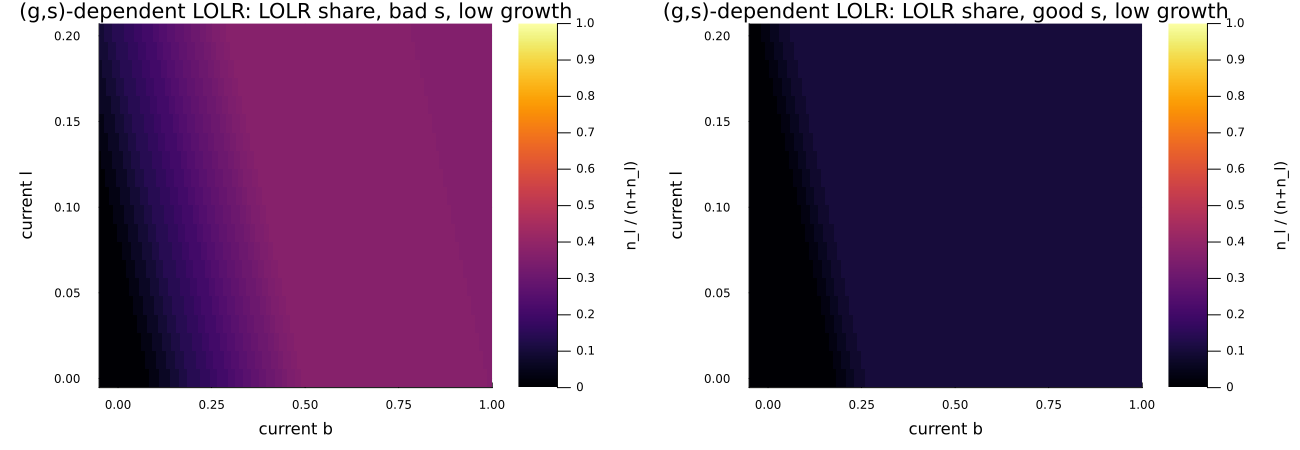

In [17]:
p1 = heatmap(
    model.b, model.l, pol_bad.share',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dependent LOLR: LOLR share, bad s, low growth",
    colorbar_title = "n_l / (n+n_l)",
    clims = (0.0, 1.0),
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

p2 = heatmap(
    model.b, model.l, pol_good.share',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dependent LOLR: LOLR share, good s, low growth",
    colorbar_title = "n_l / (n+n_l)",
    clims = (0.0, 1.0),
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

plot(p1, p2, layout = (1, 2), size = (1300, 450))


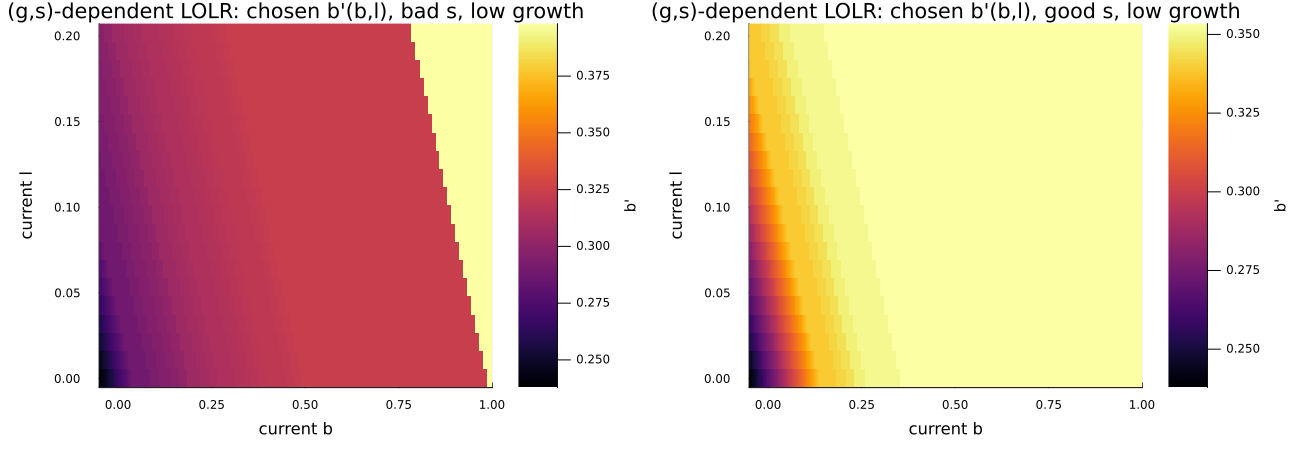

In [18]:
p1 = heatmap(
    model.b, model.l, pol_bad.bprime',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dependent LOLR: chosen b'(b,l), bad s, low growth",
    colorbar_title = "b'",
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

p2 = heatmap(
    model.b, model.l, pol_good.bprime',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dependent LOLR: chosen b'(b,l), good s, low growth",
    colorbar_title = "b'",
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

plot(p1, p2, layout = (1, 2), size = (1300, 450))


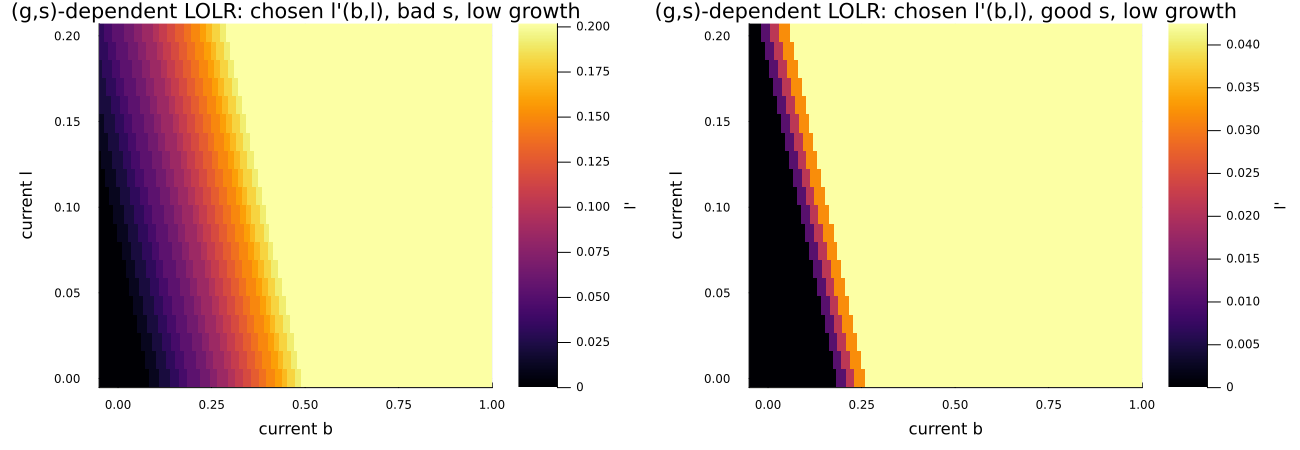

In [19]:
p1 = heatmap(
    model.b, model.l, pol_bad.lprime',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dependent LOLR: chosen l'(b,l), bad s, low growth",
    colorbar_title = "l'",
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

p2 = heatmap(
    model.b, model.l, pol_good.lprime',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dependent LOLR: chosen l'(b,l), good s, low growth",
    colorbar_title = "l'",
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

plot(p1, p2, layout = (1, 2), size = (1300, 450))


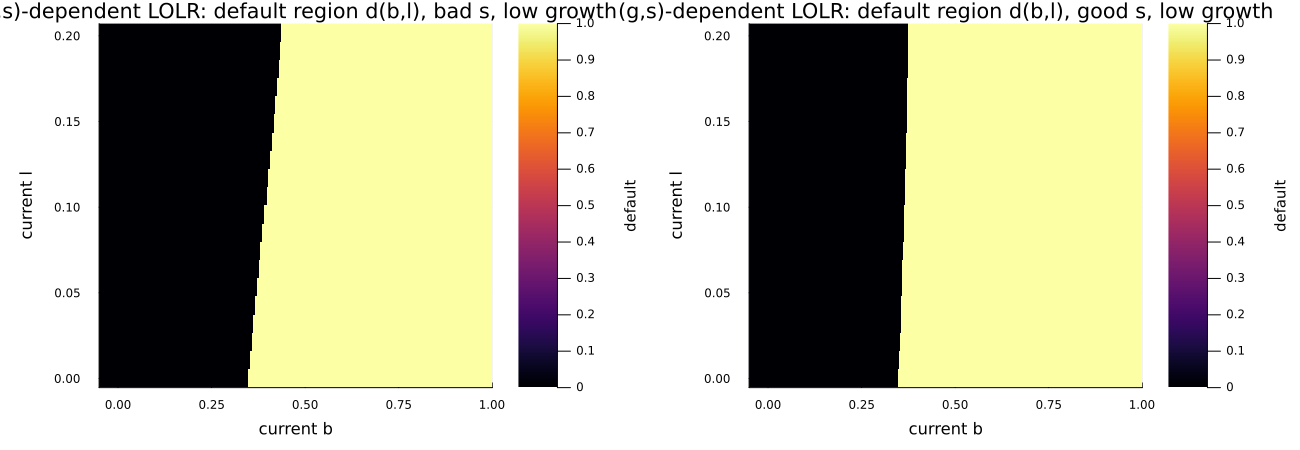

In [20]:
p1 = heatmap(
    model.b, model.l, pol_bad.d',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dependent LOLR: default region d(b,l), bad s, low growth",
    colorbar_title = "default",
    clims = (0.0, 1.0),
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

p2 = heatmap(
    model.b, model.l, pol_good.d',
    xlabel = "current b",
    ylabel = "current l",
    title = "(g,s)-dependent LOLR: default region d(b,l), good s, low growth",
    colorbar_title = "default",
    clims = (0.0, 1.0),
    left_margin = 10Plots.mm,
    bottom_margin = 8Plots.mm,
)

plot(p1, p2, layout = (1, 2), size = (1300, 450))


## Simulation Tables

Simulate the current scenario, save its summary statistics, and append its moments to the baseline `s_lolr` LaTeX tables.

## Saved Scenario Summary

The next block writes a compact serialized summary of this scenario so the comparison notebook can build multi-scenario LaTeX tables without resolving the model.

In [21]:
# Simulate the current scenario, save a compact summary, and compute table moments.
using Printf
using Serialization

function _v2_notebook_dir()
    return isfile("src/simple_s_lolr_v2.jl") ? pwd() : joinpath(pwd(), "1period_s_lolr_v2")
end

function _v2_transition_moments(sim, model; burnin = 10_000)
    T = length(sim.default)
    @assert 1 <= burnin < T
    high_idx = argmax(model.g)
    low_idx = argmin(model.g)
    starts = falses(T)
    gh_to_gl = falses(T)
    nd_before = falses(T)

    for t in 2:T
        starts[t] = sim.default[t] && !sim.default[t - 1]
        gh_to_gl[t] = sim.g_idx[t - 1] == high_idx && sim.g_idx[t] == low_idx
        nd_before[t] = !sim.default[t - 1]
    end

    sample = (burnin + 1):T
    default_starts = starts[sample]
    gh_to_gl_sample = gh_to_gl[sample]
    nd_before_sample = nd_before[sample]
    coincident = default_starts .& gh_to_gl_sample
    denom_default_starts = sum(default_starts)
    denom_transitions = sum(gh_to_gl_sample .& nd_before_sample)

    pct_default_starts_ghgl = denom_default_starts > 0 ? 100 * sum(coincident) / denom_default_starts : NaN
    pct_ghgl_end_default = denom_transitions > 0 ? 100 * sum(coincident) / denom_transitions : NaN

    return (
        pct_default_starts_ghgl = pct_default_starts_ghgl,
        pct_ghgl_end_default = pct_ghgl_end_default,
    )
end

function _append_column_to_latex_table(src_path, dst_path, header_top, header_bottom, row_values)
    lines = readlines(src_path)
    new_lines = String[]
    pair_idx = 1

    for line in lines
        if occursin("\\begin{tabular}", line)
            push!(new_lines, replace(line, r"\}$" => "||c}"))
        elseif occursin("\\cline{2-", line)
            m = match(r"\\cline\{2-(\d+)\}", line)
            ncols = parse(Int, m.captures[1]) + 1
            push!(new_lines, replace(line, r"\\cline\{2-\d+\}" => "\\cline{2-$(ncols)}"))
        elseif occursin("\\multicolumn{11}{l}", line)
            push!(new_lines, replace(line, "\\multicolumn{11}{l}" => "\\multicolumn{12}{l}"))
        elseif startswith(line, "Moment & ")
            push!(new_lines, replace(line, "\\\\" => " & \\multicolumn{1}{c}{$(header_top)} \\\\"))
        elseif startswith(line, " & \$P_b=1\\%\$")
            push!(new_lines, replace(line, "\\\\" => " & $(header_bottom) \\\\"))
        else
            label = split(line, " & "; limit = 2)[1]
            if row_values isa AbstractDict
                if haskey(row_values, label)
                    push!(new_lines, replace(line, "\\\\" => " & $(row_values[label]) \\\\"))
                else
                    push!(new_lines, line)
                end
            elseif row_values isa AbstractVector{<:Pair}
                if pair_idx <= length(row_values) && first(row_values[pair_idx]) == label
                    push!(new_lines, replace(line, "\\\\" => " & $(last(row_values[pair_idx])) \\\\"))
                    pair_idx += 1
                else
                    push!(new_lines, line)
                end
            else
                push!(new_lines, line)
            end
        end
    end

    mkpath(dirname(dst_path))
    write(dst_path, join(new_lines, "\n") * "\n")
    return dst_path
end

scenario_meta = (
    name = "Main (σ=8, ΔLB=20, Δelse=5)",
    header_top = raw"Main",
    header_bottom = raw"$\sigma=8\%,\ \Delta_{ND,LB}=20\%,\ \Delta_{else}=5\%$",
    bundle_name = "s_lolr_v2_case_sigma8_delta20_else5.jls",
    moments_table_name = "s_lolr_v2_moments_table.tex",
    transition_table_name = "s_lolr_v2_transition_table.tex",
)

v2_notebook_dir = _v2_notebook_dir()
s_lolr_result_dir = joinpath(dirname(v2_notebook_dir), "1period_s_lolr", "result")
v2_result_dir = joinpath(v2_notebook_dir, "result")
v2_sim = simulate(model, sol; T = 200_000, seed = 1234)
v2_moments = summarize_simulation(v2_sim, model; sol = sol, burnin = 10_000)
v2_transition = _v2_transition_moments(v2_sim, model; burnin = 10_000)

v2_bundle_path = joinpath(v2_result_dir, scenario_meta.bundle_name)
mkpath(dirname(v2_bundle_path))
open(v2_bundle_path, "w") do io
    serialize(io, (scenario = scenario_meta, model = model, sol = sol))
end
println(v2_bundle_path)
nothing

/Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_s_lolr_v2/result/s_lolr_v2_case_sigma8_delta20_else5.jls


In [22]:
# Append the current scenario as a new column to the base moments table.
fmt4(x) = isnan(x) ? "NaN" : @sprintf("%.4f", x)

moment_blocks = [v2_moments.all, v2_moments.low, v2_moments.high]
moment_values = Pair{String,String}[]

for block in moment_blocks
    append!(moment_values, [
        "avg(spread)" => fmt4(block.avg_spread),
        "avg(qb/y)" => fmt4(block.avg_qb_to_y),
        "avg(f/y)" => fmt4(block.avg_f_to_y),
        "avg(n/y)" => fmt4(block.avg_n_to_y),
        "avg(n_l/y)" => fmt4(block.avg_nl_to_y),
        "avg(l/y)" => fmt4(block.avg_l_to_y),
        "avg(b/y)" => fmt4(block.avg_b_to_y),
        "avg(tb/y)" => fmt4(block.avg_tb_to_y),
        "default rate" => fmt4(block.default_rate),
    ])
end

v2_moments_path = _append_column_to_latex_table(
    joinpath(s_lolr_result_dir, "s_lolr_moments_table.tex"),
    joinpath(v2_result_dir, scenario_meta.moments_table_name),
    scenario_meta.header_top,
    scenario_meta.header_bottom,
    moment_values,
)
println(v2_moments_path)

/Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_s_lolr_v2/result/s_lolr_v2_moments_table.tex


In [23]:
# Append the current scenario as a new column to the base transition table.
fmt2(x) = isnan(x) ? "NaN" : @sprintf("%.2f", x)

transition_values = Dict(
    raw"\% of default starts by $g_H \to g_L$" => fmt2(v2_transition.pct_default_starts_ghgl),
    raw"\% of $g_H \to g_L$ ends in default" => fmt2(v2_transition.pct_ghgl_end_default),
)

v2_transition_path = _append_column_to_latex_table(
    joinpath(s_lolr_result_dir, "s_lolr_transition_table.tex"),
    joinpath(v2_result_dir, scenario_meta.transition_table_name),
    scenario_meta.header_top,
    scenario_meta.header_bottom,
    transition_values,
)
println(v2_transition_path)

/Users/erfanahar/Dropbox/Research/Sovereign Debt and Stagnation/1period_s_lolr_v2/result/s_lolr_v2_transition_table.tex


In [24]:
# Helper objects for low-growth policy and schedule plots in v2.
gi_low = argmin(model.g)
ei_mid = cld(model.Ne, 2)
s_bad = 1
s_good = min(2, model.Ns)
li_zero = findmin(abs.(model.l))[2]
bi_zero = findmin(abs.(model.b))[2]
lprime_zero = findmin(abs.(model.l))[2]

mask_bad = sol.schedule_mask[:, lprime_zero, gi_low, s_bad]
mask_good = sol.schedule_mask[:, lprime_zero, gi_low, s_good]
schedule_bad = (n = sol.n[mask_bad, lprime_zero, gi_low, s_bad], R = sol.R[mask_bad, lprime_zero, gi_low, s_bad])
schedule_good = (n = sol.n[mask_good, lprime_zero, gi_low, s_good], R = sol.R[mask_good, lprime_zero, gi_low, s_good])
nothing


## Policy and Schedule Figures

These figures show the conditional private schedule, private issuance policy, LOLR issuance policy, and default policy under the current `(g,s)`-dependent LOLR calibration.

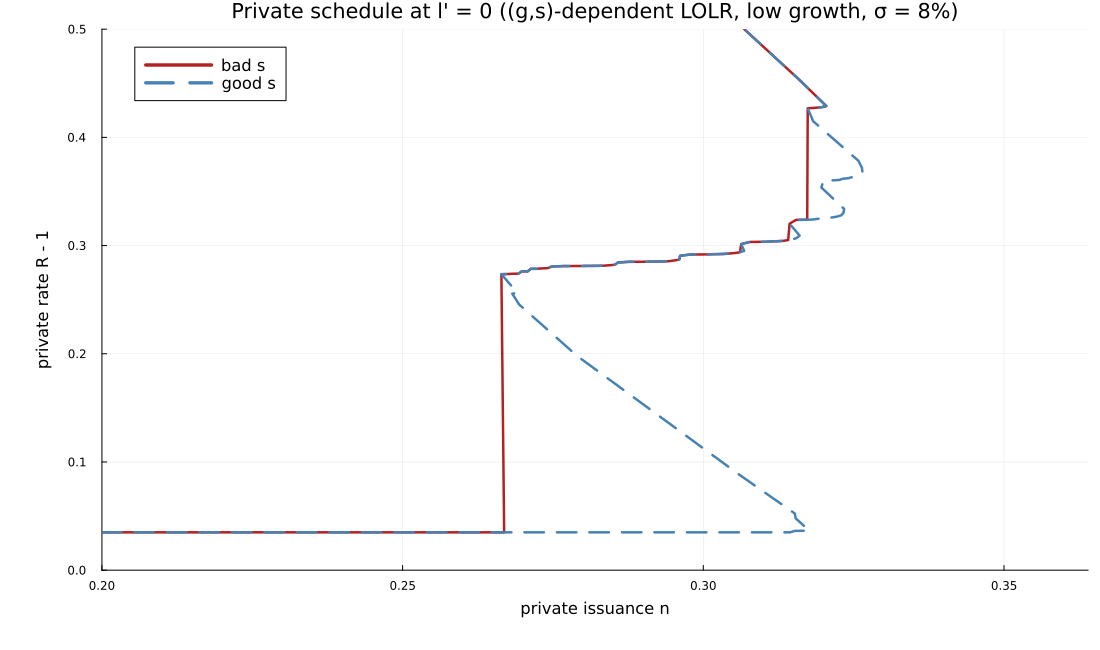

In [25]:
# Private schedule R(n) at l' = 0 in the current state-dependent LOLR model.
p_v2_schedule = plot(
    schedule_bad.n,
    schedule_bad.R .- 1,
    color = :firebrick,
    linestyle = :solid,
    linewidth = 2.5,
    label = "bad s",
    xlabel = "private issuance n",
    ylabel = "private rate R - 1",
    title = "Private schedule at l' = 0 ((g,s)-dependent LOLR, low growth, σ = 8%)",
    legend = :topleft,
    legendfontsize = 11,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (1100, 650),
    ylims = (0.0, 0.5),
    xlims = (0.2, 0.364),
)
plot!(p_v2_schedule, schedule_good.n, schedule_good.R .- 1, color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good s")
v2_schedule_path = joinpath("result", "s_lolr_v2_low_growth_selected_schedule.png")
savefig(p_v2_schedule, v2_schedule_path)
(v2_schedule_path = v2_schedule_path, figure = p_v2_schedule)
display(p_v2_schedule)


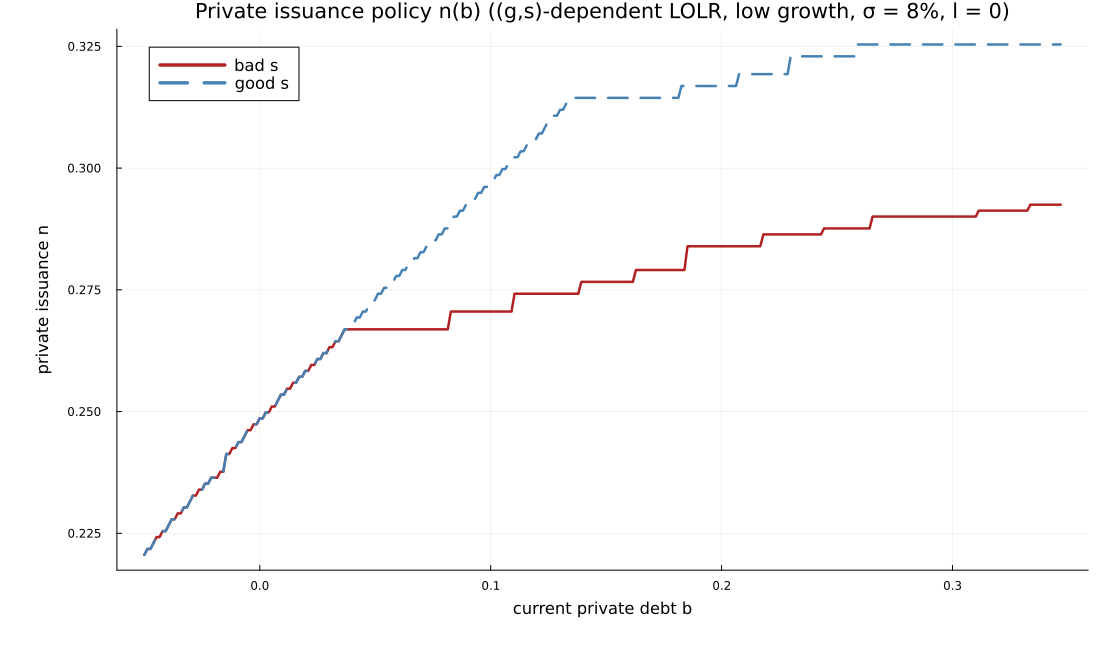

In [26]:
# Private borrowing policy n(b) in the current state-dependent LOLR model.
bad_bp = sol.b_policy_idx[:, li_zero, gi_low, s_bad, ei_mid]
bad_lp = sol.l_policy_idx[:, li_zero, gi_low, s_bad, ei_mid]
good_bp = sol.b_policy_idx[:, li_zero, gi_low, s_good, ei_mid]
good_lp = sol.l_policy_idx[:, li_zero, gi_low, s_good, ei_mid]
bad_n = [sol.n[bad_bp[bi], bad_lp[bi], gi_low, s_bad] for bi in 1:model.Nb]
good_n = [sol.n[good_bp[bi], good_lp[bi], gi_low, s_good] for bi in 1:model.Nb]
bad_repay = .!sol.d[:, li_zero, gi_low, s_bad, ei_mid]
good_repay = .!sol.d[:, li_zero, gi_low, s_good, ei_mid]

p_v2_nb = plot(
    model.b[bad_repay],
    bad_n[bad_repay],
    color = :firebrick,
    linestyle = :solid,
    linewidth = 2.5,
    label = "bad s",
    xlabel = "current private debt b",
    ylabel = "private issuance n",
    title = "Private issuance policy n(b) ((g,s)-dependent LOLR, low growth, σ = 8%, l = 0)",
    legend = :topleft,
    legendfontsize = 11,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (1100, 650),
)
plot!(p_v2_nb, model.b[good_repay], good_n[good_repay], color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good s")
v2_nb_path = joinpath("result", "s_lolr_v2_low_growth_private_policy.png")
savefig(p_v2_nb, v2_nb_path)
(v2_nb_path = v2_nb_path, figure = p_v2_nb)
display(p_v2_nb)


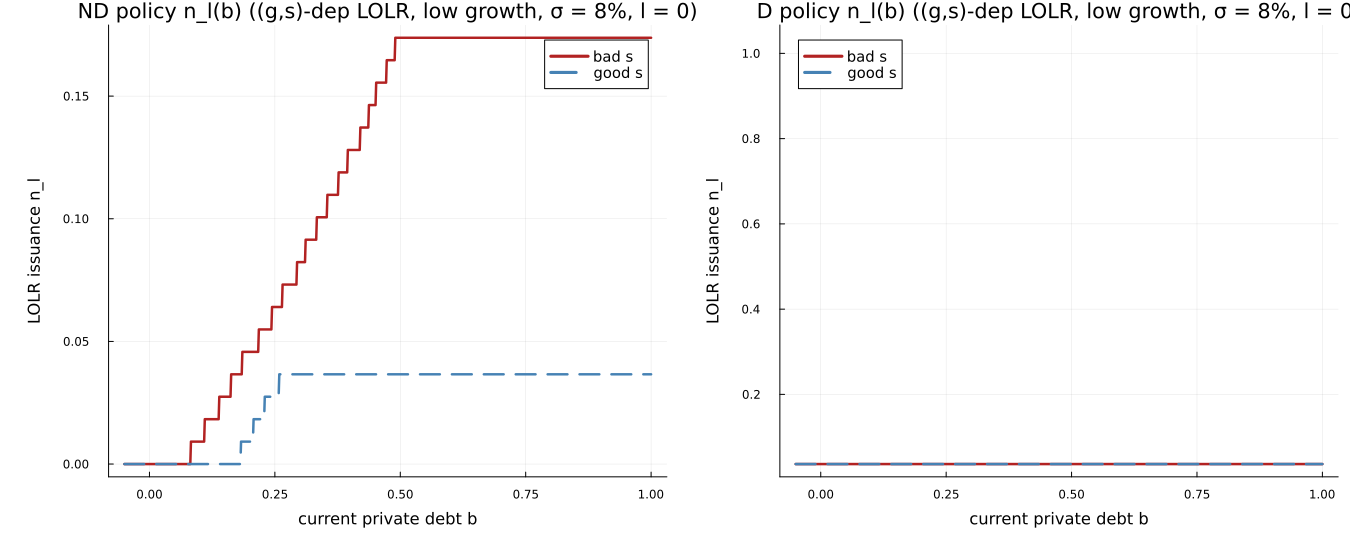

In [27]:
# LOLR borrowing policy n_l(b) in the current state-dependent LOLR model.
bad_lp_nd = sol.l_policy_idx[:, li_zero, gi_low, s_bad, ei_mid]
good_lp_nd = sol.l_policy_idx[:, li_zero, gi_low, s_good, ei_mid]
bad_lp_d = sol.l_policy_idx_d[:, li_zero, gi_low, s_bad, ei_mid]
good_lp_d = sol.l_policy_idx_d[:, li_zero, gi_low, s_good, ei_mid]
bad_nl_nd = (model.g[gi_low] .* model.l[bad_lp_nd]) ./ model.R_l
good_nl_nd = (model.g[gi_low] .* model.l[good_lp_nd]) ./ model.R_l
bad_nl_d = (model.g[gi_low] .* model.l[bad_lp_d]) ./ model.R_l
good_nl_d = (model.g[gi_low] .* model.l[good_lp_d]) ./ model.R_l

p_v2_nl_nd = plot(
    model.b,
    bad_nl_nd,
    color = :firebrick,
    linestyle = :solid,
    linewidth = 2.5,
    label = "bad s",
    xlabel = "current private debt b",
    ylabel = "LOLR issuance n_l",
    title = "ND policy n_l(b) ((g,s)-dep LOLR, low growth, σ = 8%, l = 0)",
    legend = :topright,
    legendfontsize = 10,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (700, 600),
)
plot!(p_v2_nl_nd, model.b, good_nl_nd, color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good s")

p_v2_nl_d = plot(
    model.b,
    bad_nl_d,
    color = :firebrick,
    linestyle = :solid,
    linewidth = 2.5,
    label = "bad s",
    xlabel = "current private debt b",
    ylabel = "LOLR issuance n_l",
    title = "D policy n_l(b) ((g,s)-dep LOLR, low growth, σ = 8%, l = 0)",
    legend = :topleft,
    legendfontsize = 10,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (700, 600),
)
plot!(p_v2_nl_d, model.b, good_nl_d, color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good s")

p_v2_nl = plot(p_v2_nl_nd, p_v2_nl_d, layout = (1, 2), size = (1350, 550))
v2_nl_path = joinpath("result", "s_lolr_v2_low_growth_lolr_policy.png")
savefig(p_v2_nl, v2_nl_path)
(v2_nl_path = v2_nl_path, figure = p_v2_nl)
display(p_v2_nl)


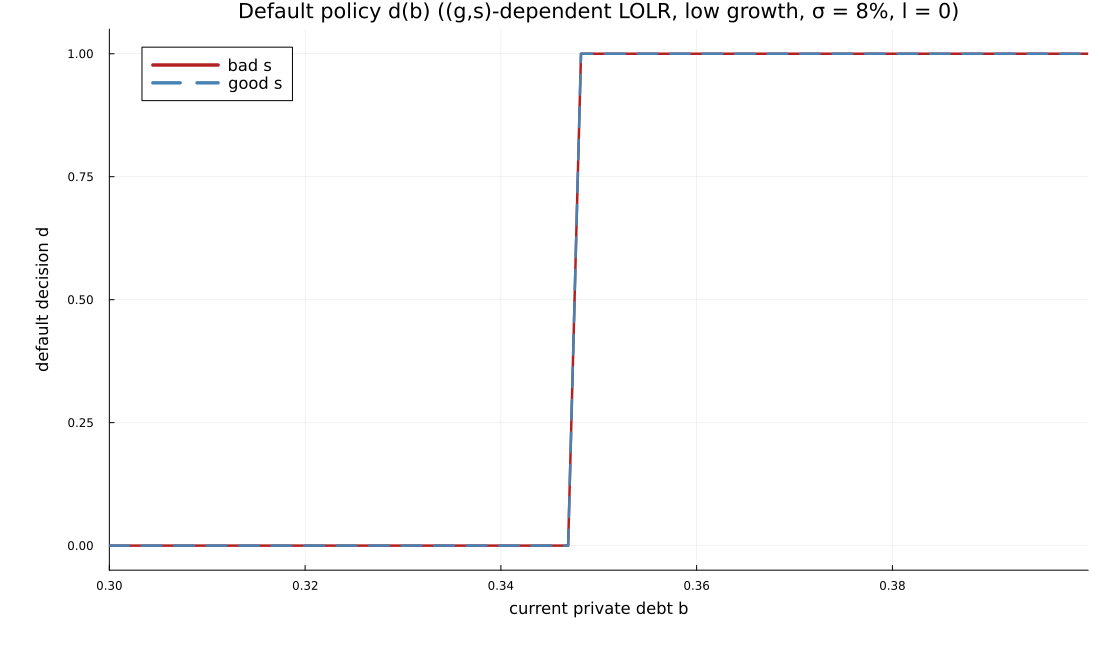

In [28]:
# Default regions d(b) in the current state-dependent LOLR model.
d_bad = Float64.(sol.d[:, li_zero, gi_low, s_bad, ei_mid])
d_good = Float64.(sol.d[:, li_zero, gi_low, s_good, ei_mid])

p_v2_default = plot(
    model.b,
    d_bad,
    color = :firebrick,
    linestyle = :solid,
    linewidth = 2.5,
    label = "bad s",
    xlabel = "current private debt b",
    ylabel = "default decision d",
    title = "Default policy d(b) ((g,s)-dependent LOLR, low growth, σ = 8%, l = 0)",
    legend = :topleft,
    legendfontsize = 11,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    ylims = (-0.05, 1.05),
    xlims = (0.3,0.4),
    size = (1100, 650),
)
plot!(p_v2_default, model.b, d_good, color = :steelblue, linestyle = :dash, linewidth = 2.5, label = "good s")
v2_default_path = joinpath("result", "s_lolr_v2_low_growth_default_policy.png")
savefig(p_v2_default, v2_default_path)
(v2_default_path = v2_default_path, figure = p_v2_default)
display(p_v2_default)


## Simulation Distributions

These plots summarize the simulated distribution of private issuance and the distribution of carried debt and LOLR issuance around `g_H \to g_L` transitions.

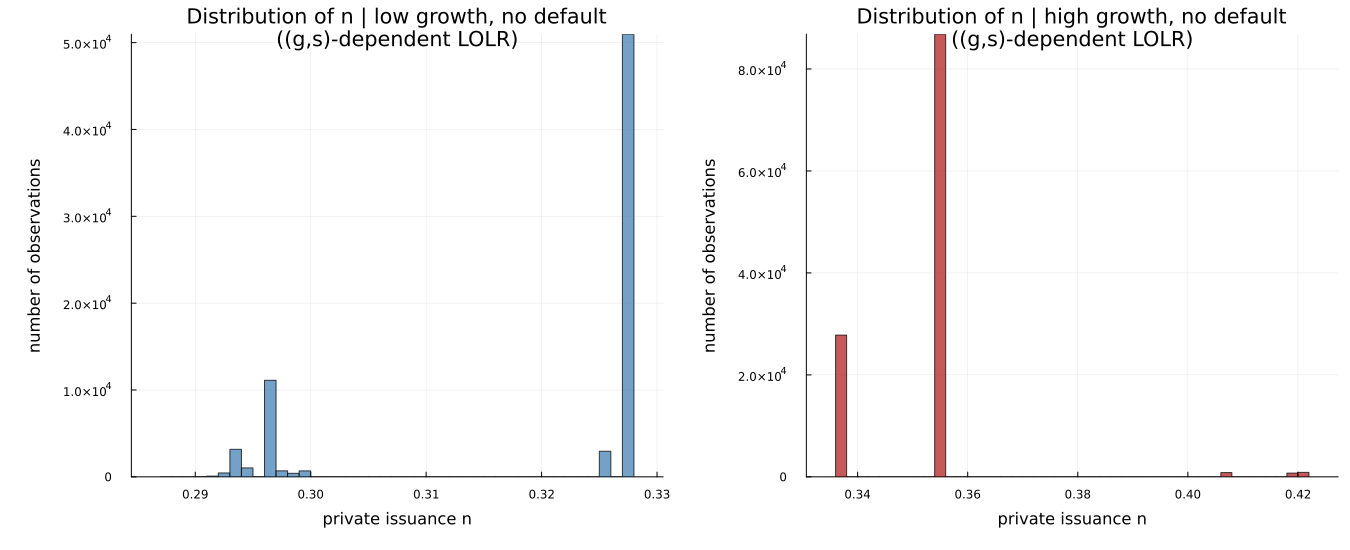

In [29]:
# Distribution of private issuance n in the state-dependent LOLR simulation.
burnin_n_dist = 10_000
sample_idx = (burnin_n_dist + 1):length(v2_sim.n)
nondefault_sample = .!v2_sim.default[sample_idx]
g_sample = v2_sim.g_idx[sample_idx]
n_sample = v2_sim.n[sample_idx]
g_low_idx = argmin(model.g)
g_high_idx = argmax(model.g)

mask_low_nd = nondefault_sample .& (g_sample .== g_low_idx)
mask_high_nd = nondefault_sample .& (g_sample .== g_high_idx)

p_n_low = histogram(
    n_sample[mask_low_nd],
    bins = 40,
    color = :steelblue,
    alpha = 0.75,
    xlabel = "private issuance n",
    ylabel = "number of observations",
    title = "Distribution of n | low growth, no default\n((g,s)-dependent LOLR)",
    legend = false,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (700, 550),
)

p_n_high = histogram(
    n_sample[mask_high_nd],
    bins = 40,
    color = :firebrick,
    alpha = 0.75,
    xlabel = "private issuance n",
    ylabel = "number of observations",
    title = "Distribution of n | high growth, no default\n((g,s)-dependent LOLR)",
    legend = false,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (700, 550),
)

p_v2_n_dist = plot(p_n_low, p_n_high, layout = (1, 2), size = (1350, 550))
v2_n_dist_path = joinpath("result", "s_lolr_v2_issuance_distribution.png")
savefig(p_v2_n_dist, v2_n_dist_path)
(v2_n_dist_path = v2_n_dist_path, figure = p_v2_n_dist)
display(p_v2_n_dist)


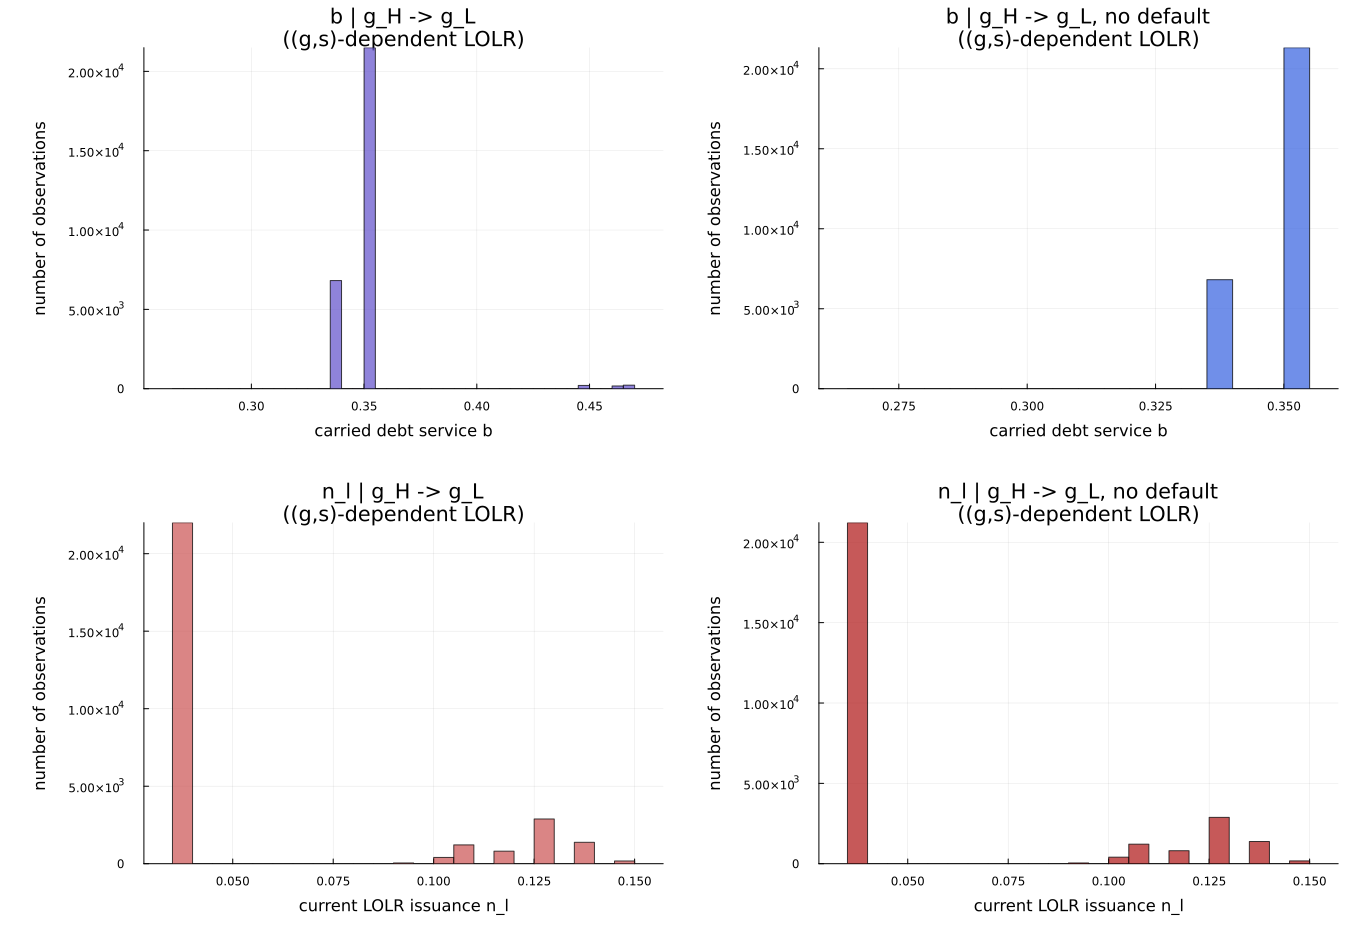

In [30]:
# Distributions at g_H -> g_L transitions in the state-dependent LOLR simulation.
burnin_transition_dist = 10_000
sample_idx = (burnin_transition_dist + 1):length(v2_sim.b)
g_high_idx = argmax(model.g)
g_low_idx = argmin(model.g)

gh_to_gl = falses(length(v2_sim.b))
for t in 2:length(v2_sim.b)
    gh_to_gl[t] = v2_sim.g_idx[t - 1] == g_high_idx && v2_sim.g_idx[t] == g_low_idx
end

transition_mask = gh_to_gl[sample_idx]
nondefault_mask = .!v2_sim.default[sample_idx]
transition_nd_mask = transition_mask .& nondefault_mask

b_transition = v2_sim.b[sample_idx][transition_mask]
b_transition_nd = v2_sim.b[sample_idx][transition_nd_mask]
nl_transition = v2_sim.n_l[sample_idx][transition_mask]
nl_transition_nd = v2_sim.n_l[sample_idx][transition_nd_mask]

p_b_all = histogram(
    b_transition,
    bins = 40,
    color = :slateblue,
    alpha = 0.75,
    xlabel = "carried debt service b",
    ylabel = "number of observations",
    title = "b | g_H -> g_L\n((g,s)-dependent LOLR)",
    legend = false,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (700, 500),
)

p_b_nd = histogram(
    b_transition_nd,
    bins = 40,
    color = :royalblue,
    alpha = 0.75,
    xlabel = "carried debt service b",
    ylabel = "number of observations",
    title = "b | g_H -> g_L, no default\n((g,s)-dependent LOLR)",
    legend = false,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (700, 500),
)

p_nl_all = histogram(
    nl_transition,
    bins = 40,
    color = :indianred,
    alpha = 0.75,
    xlabel = "current LOLR issuance n_l",
    ylabel = "number of observations",
    title = "n_l | g_H -> g_L\n((g,s)-dependent LOLR)",
    legend = false,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (700, 500),
)

p_nl_nd = histogram(
    nl_transition_nd,
    bins = 40,
    color = :firebrick,
    alpha = 0.75,
    xlabel = "current LOLR issuance n_l",
    ylabel = "number of observations",
    title = "n_l | g_H -> g_L, no default\n((g,s)-dependent LOLR)",
    legend = false,
    left_margin = 12Plots.mm,
    bottom_margin = 10Plots.mm,
    size = (700, 500),
)

p_v2_transition_dist = plot(p_b_all, p_b_nd, p_nl_all, p_nl_nd, layout = (2, 2), size = (1350, 950))
v2_transition_dist_path = joinpath("result", "s_lolr_v2_transition_distributions.png")
savefig(p_v2_transition_dist, v2_transition_dist_path)
(v2_transition_dist_path = v2_transition_dist_path, figure = p_v2_transition_dist)
display(p_v2_transition_dist)
